***EX NO 10 - RECOMMENDATION SYSTEM USING MATRIX FACTORIZATION ( SVD & NMF )***


**DATE: 01.04.2026**

**-SREENIDHI S (24BAD114)**

SCENARIO 1 – MATRIX FACTORIZATION USING SVD



**Problem Statement**

Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.



Dataset (Kaggle – Public)

https://www.kaggle.com/datasets/grouplens/movielens-100k


**Target Variable:** Predicted ratings for unseen movies

**Input Feature:  **

• User ID

• Movie ID

• Ratings



**IN-LAB TASKS**

Import required Python libraries (NumPy, Pandas, Scikit-learn, Surprise, etc.)

Load the MovieLens dataset

Perform data preprocessing

Create User-Item Interaction Matrix

Normalize the matrix (optional – mean centering)

Apply SVD decomposition

Reduce dimensions (select k latent factors)

Reconstruct the matrix

Predict missing ratings

Generate Top-N recommendations







**Evaluation Metrics**

• RMSE (Root Mean Square Error)

• MAE (Mean Absolute Error)



**Analysis Tasks**

• Analyze effect of number of latent factors (k)

• Compare predicted vs actual ratings

• Observe how dimensionality reduction improves performance

• Study overfitting vs underfitting







**Visualization**

• Heatmap of original vs reconstructed matrix
• Error vs number of latent factors
• Top recommended movies

SREENIDHI-24BAD114
   userId  movieId  rating   timestamp
0       1       16     4.0  1217897793
1       1       24     1.5  1217895807
2       1       32     4.0  1217896246
3       1       47     4.0  1217896556
4       1       50     4.0  1217896523
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
k = 10 RMSE: 2.5702136755416625 MAE: 2.224034874281896
k = 20 RMSE: 2.3711532336302934 MAE: 1.9663625478200848
k = 30 RMSE: 2.239539003988078 MAE: 1.794

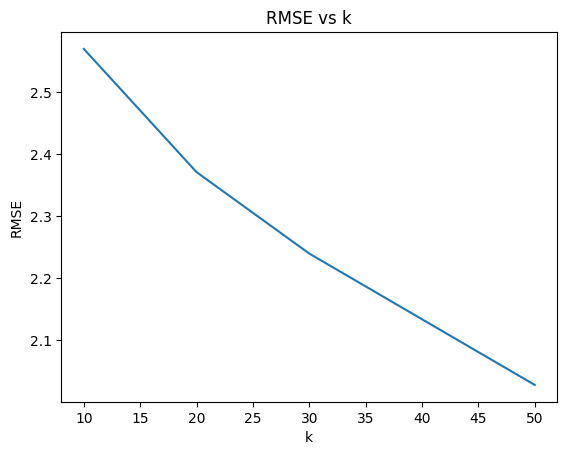

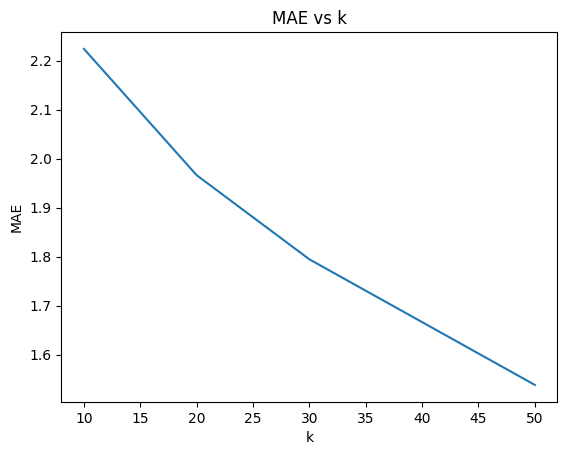

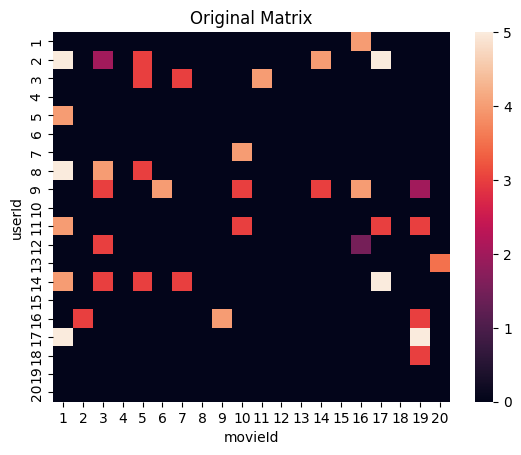

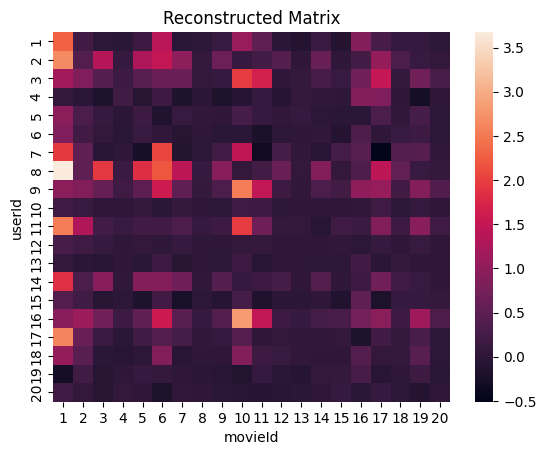

In [4]:
print("SREENIDHI-24BAD114")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from numpy.linalg import svd

ratings = pd.read_csv("/content/ratings.csv")
movies = pd.read_csv("/content/movies.csv")

print(ratings.head())
print(movies.head())

user_item = ratings.pivot(index='userId', columns='movieId', values='rating')

user_item_filled = user_item.fillna(0)

mean_user_rating = np.mean(user_item_filled, axis=1)

user_item_centered = user_item_filled.sub(mean_user_rating, axis=0)

U, sigma, Vt = svd(user_item_centered, full_matrices=False)

k_values = [10, 20, 30, 50]

rmse_list = []
mae_list = []

for k in k_values:
    sigma_k = np.diag(sigma[:k])
    U_k = U[:, :k]
    Vt_k = Vt[:k, :]
    reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)
    reconstructed += mean_user_rating.values.reshape(-1, 1)

    actual = user_item.values
    mask = ~np.isnan(actual)

    pred = reconstructed[mask]
    actual_vals = actual[mask]

    rmse = np.sqrt(mean_squared_error(actual_vals, pred))
    mae = mean_absolute_error(actual_vals, pred)

    print("k =", k, "RMSE:", rmse, "MAE:", mae)

    rmse_list.append(rmse)
    mae_list.append(mae)

k = 20

sigma_k = np.diag(sigma[:k])
U_k = U[:, :k]
Vt_k = Vt[:k, :]

reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)
reconstructed += mean_user_rating.values.reshape(-1, 1)

reconstructed_df = pd.DataFrame(reconstructed, index=user_item.index, columns=user_item.columns)

user_id = 1

user_ratings = user_item.loc[user_id]
predicted_ratings = reconstructed_df.loc[user_id]

unseen = user_ratings[user_ratings.isna()].index

recommendations = predicted_ratings[unseen].sort_values(ascending=False).head(10)

recommended_movies = movies[movies['movieId'].isin(recommendations.index)]

print(recommended_movies[['movieId', 'title']])

plt.plot(k_values, rmse_list)
plt.title("RMSE vs k")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()

plt.plot(k_values, mae_list)
plt.title("MAE vs k")
plt.xlabel("k")
plt.ylabel("MAE")
plt.show()

sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()

SCENARIO 2 – MATRIX FACTORIZATION USING NMF



**Problem Statement**

Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.



Dataset (Same / Alternative Dataset)

Same MovieLens Dataset (or any rating dataset)



**Target Variable:** Predicted ratings / Recommendations

**Input Features**

• User ID

• Movie ID

• Ratings



**IN-LAB TASKS**  

Load dataset

Create User-Item matrix

Handle missing values (fill with 0 or mean)

Apply NMF model

Factorize into:

User-feature matrix

Item-feature matrix

Reconstruct the rating matrix

Predict missing values

Generate Top-N recommendations



**Evaluation Metrics**

• RMSE

• Precision@K

• Recall@K



**Analysis Tasks**

• Compare SVD vs NMF performance

• Observe interpretability of NMF factors

• Analyze sparsity handling

• Compare recommendation diversity



**Visualization**

• Latent feature visualization
• Reconstruction comparison
• Recommendation ranking chart

SREENIDHI-24BAD114
   userId  movieId  rating   timestamp
0       1       16     4.0  1217897793
1       1       24     1.5  1217895807
2       1       32     4.0  1217896246
3       1       47     4.0  1217896556
4       1       50     4.0  1217896523
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE: 2.4639842187622807
      movieId                                              title
258       293  Léon: The Professional (a.k.a. The Professiona...
484       541                                Blade Runner (1982)
962      1200                                      Aliens (1986)
967      1206                         Clockwork Orange, A (1971)
975      1214                                       Alien (1979)
1843     2329                          American History X (1998)
3322     4226                                     Memento (2000)
3867     4973  Amelie (Fabuleux destin d'Amélie Poulain, Le) ...
5004     6874                           Kill Bill: Vol. 1 (2003)
5328     7361       Eternal Sunshine of the Spotless Mind (2004)
Precision@10: 0.9
Recall@10: 0.10714285714285714


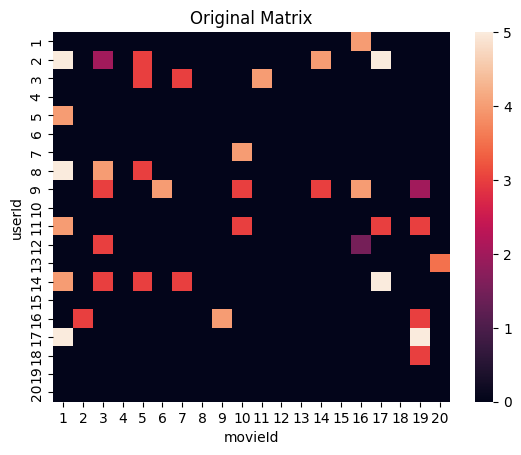

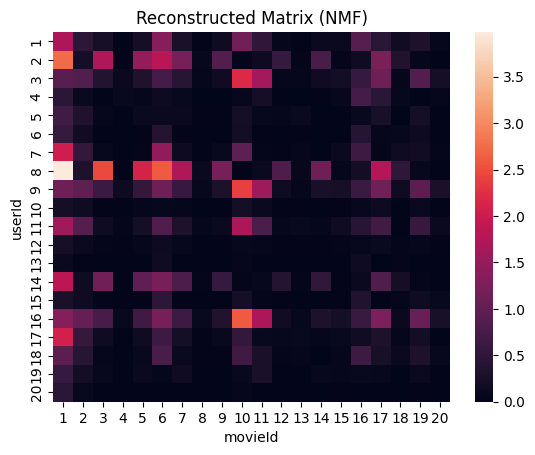

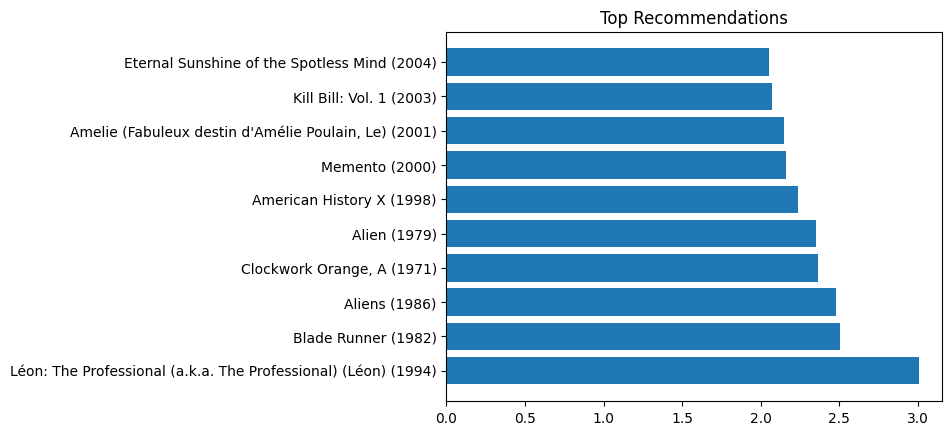

In [5]:
print("SREENIDHI-24BAD114")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

ratings = pd.read_csv("/content/ratings (1).csv")
movies = pd.read_csv("/content/movies.csv")

print(ratings.head())
print(movies.head())

user_item = ratings.pivot(index='userId', columns='movieId', values='rating')

user_item_filled = user_item.fillna(0)

model = NMF(n_components=20, init='random', random_state=42, max_iter=200)

W = model.fit_transform(user_item_filled)
H = model.components_

reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(reconstructed, index=user_item.index, columns=user_item.columns)

actual = user_item.values
mask = ~np.isnan(actual)

pred = reconstructed[mask]
actual_vals = actual[mask]

rmse = np.sqrt(mean_squared_error(actual_vals, pred))
print("RMSE:", rmse)

user_id = 1

user_actual = user_item.loc[user_id]
user_pred = reconstructed_df.loc[user_id]

unseen = user_actual[user_actual.isna()].index

top_n = user_pred[unseen].sort_values(ascending=False).head(10)

recommended_movies = movies[movies['movieId'].isin(top_n.index)]

print(recommended_movies[['movieId', 'title']])

def precision_recall_at_k(actual, predicted, k=10, threshold=3.5):
    actual_items = actual[actual >= threshold].index
    predicted_items = predicted.sort_values(ascending=False).head(k).index
    tp = len(set(actual_items) & set(predicted_items))
    precision = tp / k if k > 0 else 0
    recall = tp / len(actual_items) if len(actual_items) > 0 else 0
    return precision, recall

precision, recall = precision_recall_at_k(user_actual, user_pred)

print("Precision@10:", precision)
print("Recall@10:", recall)

plt.figure()
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure()
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix (NMF)")
plt.show()

plt.figure()
plt.barh(range(10), top_n.values)
plt.yticks(range(10), recommended_movies['title'])
plt.title("Top Recommendations")
plt.show()